In [20]:
import numpy as np
import xarray as xr
from minisom import MiniSom, _build_iteration_indexes
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import os
from itertools import product

# Function and Class Defs

In [16]:
# functions
def make_gp_anomalies(ds, method="monthly"):
    # simple monthly clim
    if method == "monthly":
        climatology = ds.groupby("time.month").mean("time")

    anomalies = ds.groupby("time.month") - climatology

    return anomalies

# min max for gp and pr
def min_max_norm(ds):
    ds_max = np.max(ds)
    ds_min = np.min(ds)
    return (ds - ds_min) / (ds_max - ds_min)

# log for pr
def log_transform(ds):
    return np.log(ds + 1)

#############################################
########### Masking & Ablation Helpers ########
#############################################

def shuffle_first_x(arr, target_subset, x):
    """Return a new array with rows of the target_subset shuffled for the first x columns only."""
    if len(target_subset) > arr.shape[0] / 2:
        print("target_subset is too large to do shuffle")
        return None

    idx = np.arange(arr.shape[0])
    not_target = np.delete(idx, target_subset)
    shuffled_not_target = np.random.permutation(not_target)[:len(target_subset)]
    
    new_arr = arr.copy()
    new_arr[target_subset, :x] = arr[shuffled_not_target, :x]
    return new_arr

def shuffle_last_x(arr, target_subset, x):
    """Return a new array with rows of the target_subset shuffled for the last x columns only."""
    if len(target_subset) > arr.shape[0] / 2:
        print("target_subset is too large to do shuffle")
        return None

    idx = np.arange(arr.shape[0])
    not_target = np.delete(idx, target_subset)
    shuffled_not_target = np.random.permutation(not_target)[:len(target_subset)]
    
    new_arr = arr.copy()
    new_arr[target_subset, x:] = arr[shuffled_not_target, x:]
    return new_arr

def mask_first_x(arr, target_subset, x, mask):
    """Return a new array with rows of the target_subset masked by provided mask"""
    new_arr = arr.copy()
    new_arr[target_subset, :x] = arr[target_subset, :x]*mask
    return new_arr

def mask_last_x(arr, target_subset, x, mask):
    """Return a new array with rows of the target_subset masked by provided mask"""
    new_arr = arr.copy()
    new_arr[target_subset, x:] = arr[target_subset, x:]*mask
    return new_arr

In [ ]:
# Helper for plotting bounding box on GP Maps
class bounding_box:
    def __init__(self, lat, lon, box_label, box_color):
        # passed array of lats and lons
        self.lat = lat
        self.lon = lon
        self.label = box_label
        self.color = box_color

    def get_box_edges(self):
        lat_min, lat_max = np.min(self.lat), np.max(self.lat)
        lon_min, lon_max = np.min(self.lon), np.max(self.lon)

        lats = [lat_min, lat_max, lat_max, lat_min, lat_min]
        lons = [lon_min, lon_min, lon_max, lon_max, lon_min]

        return lats, lons

In [4]:
# Custom MiniSom that outputs quant and validation error through epochs
# Can only use in epoch mode
class MyMiniSom(MiniSom): 
    def train(self, data, num_iteration,
              random_order=False, verbose=False,
              use_epochs=False, fixed_points=None, validation_data=None):
        """Trains the SOM.

        Parameters
        ----------
        data : np.array or list
            Data matrix.

        num_iteration : int
            If use_epochs is False, the weights will be
            updated num_iteration times. Otherwise they will be updated
            len(data)*num_iteration times.

        random_order : bool (default=False)
            If True, samples are picked in random order.
            Otherwise the samples are picked sequentially.

        verbose : bool (default=False)
            If True the status of the training will be
            printed each time the weights are updated.

        use_epochs : bool (default=False)
            If True the SOM will be trained for num_iteration epochs.
            In one epoch the weights are updated len(data) times and
            the learning rate is constat throughout a single epoch.

        fixed_points : dict (default=None)
            A dictionary k : (c_1, c_2), that will force the
            training algorithm to use the neuron with coordinates
            (c_1, c_2) as winner for the sample k instead of
            the best matching unit.
        """
        super()._check_iteration_number(num_iteration)
        super()._check_input_len(data)
        random_generator = None
        if random_order:
            random_generator = self._random_generator
        iterations = _build_iteration_indexes(len(data), num_iteration,
                                              verbose, random_generator,
                                              use_epochs)
        if use_epochs:
            def get_decay_rate(iteration_index, data_len):
                return int(iteration_index / data_len)
        else:
            def get_decay_rate(iteration_index, data_len):
                return int(iteration_index)

        if fixed_points:
            super()._check_fixed_points(fixed_points, data)
        else:
            fixed_points = {}

        train_q_error = np.zeros((num_iteration + 1))
        train_t_error = np.zeros((num_iteration + 1))
        if validation_data is not None:
            validation_q_error = np.zeros((num_iteration + 1))
            validation_t_error = np.zeros((num_iteration + 1))
        
        for t, iteration in enumerate(iterations):
            decay_rate = get_decay_rate(t, len(data))
            if t % len(data) == 0:
                qe = super().quantization_error(data)
                te = super().topographic_error(data)
                train_q_error[t // len(data)] = qe
                train_t_error[t // len(data)] = te
                
                if validation_data is not None:
                    v_qe = super().quantization_error(validation_data)
                    v_te = super().topographic_error(validation_data)
                    validation_q_error[t // len(data)] = v_qe
                    validation_t_error[t // len(data)] = v_te
                    print(f'\n quantization error -- train: {qe}; validation: {v_qe}')
                    print(f" topographic error -- train: {te}; validation: {v_te}")
                else:
                    print(f'\n quantization error -- train: {qe}')
                    print(f" topographic error -- train: {te}")
                
            super().update(data[iteration],
                        fixed_points.get(iteration,
                                         super().winner(data[iteration])),
                        decay_rate, num_iteration)

        qe = super().quantization_error(data)
        te = super().topographic_error(data)
        train_q_error[-1] = qe
        train_t_error[-1] = te

        if validation_data is not None:
            v_qe = super().quantization_error(validation_data)
            v_te = super().topographic_error(validation_data)
            validation_q_error[-1] = v_qe
            validation_t_error[-1] = v_te
            print(f'\n quantization error -- train: {qe}; validation: {v_qe}')
            print(f" topographic error -- train: {te}; validation: {v_te}")
        else:
            print(f'\n quantization error -- train: {qe}')
            print(f" topographic error -- train: {te}")
            
        
        return train_q_error, validation_q_error, train_t_error, validation_t_error

In [14]:
# sourced from https://github.com/tompollard/sammon/blob/master/sammon.py

def sammon(x, n, display = 2, inputdist = 'raw', maxhalves = 20, maxiter = 500, tolfun = 1e-9, init = 'default'):

    import numpy as np 
    from scipy.spatial.distance import cdist

    """Perform Sammon mapping on dataset x

    y = sammon(x) applies the Sammon nonlinear mapping procedure on
    multivariate data x, where each row represents a pattern and each column
    represents a feature.  On completion, y contains the corresponding
    co-ordinates of each point on the map.  By default, a two-dimensional
    map is created.  Note if x contains any duplicated rows, SAMMON will
    fail (ungracefully). 

    [y,E] = sammon(x) also returns the value of the cost function in E (i.e.
    the stress of the mapping).

    An N-dimensional output map is generated by y = sammon(x,n) .

    A set of optimisation options can be specified using optional
    arguments, y = sammon(x,n,[OPTS]):

       maxiter        - maximum number of iterations
       tolfun         - relative tolerance on objective function
       maxhalves      - maximum number of step halvings
       input          - {'raw','distance'} if set to 'distance', X is 
                        interpreted as a matrix of pairwise distances.
       display        - 0 to 2. 0 least verbose, 2 max verbose.
       init           - {'pca', 'cmdscale', random', 'default'}
                        default is 'pca' if input is 'raw', 
                        'msdcale' if input is 'distance'

    The default options are retrieved by calling sammon(x) with no
    parameters.

    File        : sammon.py
    Date        : 18 April 2014
    Authors     : Tom J. Pollard (tom.pollard.11@ucl.ac.uk)
                : Ported from MATLAB implementation by 
                  Gavin C. Cawley and Nicola L. C. Talbot

    Description : Simple python implementation of Sammon's non-linear
                  mapping algorithm [1].

    References  : [1] Sammon, John W. Jr., "A Nonlinear Mapping for Data
                  Structure Analysis", IEEE Transactions on Computers,
                  vol. C-18, no. 5, pp 401-409, May 1969.

    Copyright   : (c) Dr Gavin C. Cawley, November 2007.

    This program is free software; you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation; either version 2 of the License, or
    (at your option) any later version.

    This program is distributed in the hope that it will be useful,
    but WITHOUT ANY WARRANTY; without even the implied warranty of
    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
    GNU General Public License for more details.

    You should have received a copy of the GNU General Public License
    along with this program; if not, write to the Free Software
    Foundation, Inc., 59 Temple Place, Suite 330, Boston, MA 02111-1307 USA

    """

    # Create distance matrix unless given by parameters
    if inputdist == 'distance':
        D = x
        if init == 'default':
            init = 'cmdscale'
    else:
        D = cdist(x, x)
        if init == 'default':
            init = 'pca'

    if inputdist == 'distance' and init == 'pca':
        raise ValueError("Cannot use init == 'pca' when inputdist == 'distance'")

    if np.count_nonzero(np.diagonal(D)) > 0:
        raise ValueError("The diagonal of the dissimilarity matrix must be zero")

    # Remaining initialisation
    N = x.shape[0]
    scale = 0.5 / D.sum()
    D = D + np.eye(N)     

    if np.count_nonzero(D<=0) > 0:
        raise ValueError("Off-diagonal dissimilarities must be strictly positive")   

    Dinv = 1 / D
    if init == 'pca':
        [UU,DD,_] = np.linalg.svd(x)
        y = UU[:,:n]*DD[:n] 
    elif init == 'cmdscale':
        from cmdscale import cmdscale
        y,e = cmdscale(D)
        y = y[:,:n]
    else:
        y = np.random.normal(0.0,1.0,[N,n])
    one = np.ones([N,n])
    d = cdist(y,y) + np.eye(N)
    dinv = 1. / d
    delta = D-d 
    E = ((delta**2)*Dinv).sum() 

    # Get on with it
    for i in range(maxiter):

        # Compute gradient, Hessian and search direction (note it is actually
        # 1/4 of the gradient and Hessian, but the step size is just the ratio
        # of the gradient and the diagonal of the Hessian so it doesn't
        # matter).
        delta = dinv - Dinv
        deltaone = np.dot(delta,one)
        g = np.dot(delta,y) - (y * deltaone)
        dinv3 = dinv ** 3
        y2 = y ** 2
        H = np.dot(dinv3,y2) - deltaone - np.dot(2,y) * np.dot(dinv3,y) + y2 * np.dot(dinv3,one)
        s = -g.flatten(order='F') / np.abs(H.flatten(order='F'))
        y_old    = y

        # Use step-halving procedure to ensure progress is made
        for j in range(maxhalves):
            s_reshape = np.reshape(s, (-1,n),order='F')
            y = y_old + s_reshape
            d = cdist(y, y) + np.eye(N)
            dinv = 1 / d
            delta = D - d
            E_new = ((delta**2)*Dinv).sum()
            if E_new < E:
                break
            else:
                s = 0.5*s

        # Bomb out if too many halving steps are required
        if j == maxhalves-1:
            print('Warning: maxhalves exceeded. Sammon mapping may not converge...')

        # Evaluate termination criterion
        if abs((E - E_new) / E) < tolfun:
            if display:
                print('TolFun exceeded: Optimisation terminated')
            break

        # Report progress
        E = E_new
        if display > 1:
            print('epoch = %d : E = %12.10f'% (i+1, E * scale))

    if i == maxiter-1:
        print('Warning: maxiter exceeded. Sammon mapping may not have converged...')

    # Fiddle stress to match the original Sammon paper
    E = E * scale
    
    return [y,E]

# Data Read and Process

In [5]:
########################
###### INTAKE ######
########################
# gp open and anom calc
gp_loc = "/ocean/projects/ees210011p/hdoubler/AOSC650/era5/coarse/"
gp_files = ["gp_500mb_2019.nc", "gp_500mb_2020.nc", "gp_500mb_2021.nc", "gp_500mb_2022.nc", "gp_500mb_2023.nc"]

print("Opening gp data ...")
ds = xr.open_mfdataset([os.path.join(gp_loc, f) for f in gp_files])

print("Calculating gp anoms ...")
gp_anoms = make_gp_anomalies(ds, method="monthly")
# capture average before min/max transform

# only choose precip times that exceed 0.05 mm/hr
df = pd.read_csv("/ocean/projects/ees210011p/hdoubler/AOSC650/mswep/trimmed_precip_stats3.csv", parse_dates=["time"]).set_index("time")
filtered_df = df[(df["drizzle_exceedance"] > 0.05)]
times = filtered_df.index

# select gp_subset
gp_subset = gp_anoms.sel(time=times)["z"].chunk({"time": len(times)})
print(gp_subset)
gp_subset_avg = np.average(gp_subset)

# open pr_subset
pr_loc = "/ocean/projects/ees210011p/hdoubler/AOSC650/mswep/trimmed_annual/"
pr_files = os.listdir(pr_loc)

print("Opening pr data ...")
ds = xr.open_mfdataset([os.path.join(pr_loc, f) for f in pr_files])

pr_subset = ds.sel(time=times)["precipitation"]
print(pr_subset)
ds.close()

print("DONE")

Opening gp data ...
Calculating gp anoms ...
<xarray.DataArray 'z' (time: 10700, latitude: 20, longitude: 30)> Size: 51MB
dask.array<rechunk-merge, shape=(10700, 20, 30), dtype=float64, chunksize=(10700, 20, 30), chunktype=numpy.ndarray>
Coordinates:
  * time           (time) datetime64[ns] 86kB 2019-01-01 ... 2023-12-27T02:00:00
    number         (time) int64 86kB dask.array<chunksize=(10700,), meta=np.ndarray>
    step           (time) timedelta64[ns] 86kB dask.array<chunksize=(10700,), meta=np.ndarray>
    isobaricInhPa  (time) float64 86kB dask.array<chunksize=(10700,), meta=np.ndarray>
    valid_time     (time) datetime64[ns] 86kB dask.array<chunksize=(10700,), meta=np.ndarray>
    month          (time) int64 86kB dask.array<chunksize=(10700,), meta=np.ndarray>
  * latitude       (latitude) float64 160B 30.38 31.38 32.38 ... 48.38 49.38
  * longitude      (longitude) float64 240B -129.6 -128.6 ... -101.6 -100.6
Opening pr data ...
<xarray.DataArray 'precipitation' (time: 10700, l

In [6]:
####################################
###### Scale and Transform ######
####################################
gp_scaled = gp_subset.stack(features=("latitude", "longitude"))
pr_scaled = pr_subset.stack(features=("lat", "lon"))

gp_scaled = min_max_norm(gp_scaled).values

pr_scaled = log_transform(pr_scaled)
pr_scaled = min_max_norm(pr_scaled).values

samples = np.concatenate((gp_scaled, pr_scaled), axis=1)

print("Done")

Done


# Training

In [7]:
# SOM hyperparameters

# set som lattice dimensions (i.e., number of nodes)
som_grid_rows = 5
som_grid_columns = 5

# number of weights per node
input_length = samples.shape[1]

# Spread of the neighborhood function, needs to be adequate to the dimensions
# of the map. (rows/columns minus 1 usually)
sigma = 4.0

# initial learning rate (at the iteration t we have learning_rate(t) =
# learning_rate / (1 + t/T) where T is #num_iteration/2)
learning_rate = 0.5

# def inverse_decay_to_min(learning_rate, t, max_iter):
#     MIN = 0.01
#     C = max_iter / 100.0
#     return (learning_rate * C / (C + t)) + MIN

# Function that reduces learning_rate at each iteration (i.e., epochs)
# Possible values: 'inverse_decay_to_zero', 'linear_decay_to_zero', 'asymptotic_decay'
# 'inverse_decay_to_zero' == > C = max_iter / 100.0; where, learning_rate * C / (C + t)
# 'linear_decay_to_zero' == > learning_rate * (1 - t / max_iter)
# 'asymptotic_decay' == > dynamic_parameter / (1 + t / (max_iter / 2))
# ^^Decay function of the learning process and sigma that decays these values asymptotically to 1/3 of their original values.
#decay_function=inverse_decay_to_min
decay_function='asymptotic_decay'

# Function that reduces sigma at each iteration.
# Possible values: 'inverse_decay_to_one', 'linear_decay_to_one', 'asymptotic_decay'
# 'inverse_decay_to_one' == > C = (sigma - 1) / max_iter; where, sigma / (1 + (t * C))
# 'linear_decay_to_one' == > sigma + (t * (1 - sigma) / max_iter)
sigma_decay_function='asymptotic_decay'

# Function that weights the neighborhood of a position in the map.
# Possible values: 'gaussian', 'mexican_hat', 'bubble', 'triangle',
# which takes in sigma.
neighborhood_function = 'gaussian'

# Topology of the map; Possible values: 'rectangular', 'hexagonal'
topology = 'rectangular'

# Distance used to activate the map; Possible values: 'euclidean', 'cosine', 'manhattan', 'chebyshev'
activation_distance = 'euclidean'

# Random seed to use for reproducibility. Using 1.
random_seed = 1

# lets create our som object with preset hyperparameters
som = MyMiniSom(
            som_grid_rows,
            som_grid_columns,
            input_length,
            sigma,
            learning_rate,
            decay_function,
            neighborhood_function,
            topology,
            activation_distance,
            random_seed,
            sigma_decay_function
            )

In [8]:
####################################
###### Validation Split ######
####################################
yr_indexes = filtered_df.index.year
validation_yr = 2023
valid_mask = np.zeros(len(yr_indexes), dtype=bool)
valid_mask[[i for i, yr in enumerate(yr_indexes) if yr == validation_yr]] = True

validation_set = samples[valid_mask]
train_set = samples[~valid_mask]

In [15]:
####################
###### TRAIN ######
####################

iters = 20
random_order = True
verbose = True
use_epochs = True

# let's initialize the weights
som.random_weights_init(train_set)
# som.pca_weights_init(samples)

q_error, v_q_error, t_error, v_t_error = som.train(
    train_set,
    num_iteration=iters,
    random_order=random_order,
    verbose=verbose,
    use_epochs=use_epochs,
    validation_data=validation_set
    )

 [      0 / 167560 ]   0% - ? it/s
 quantization error -- train: 2.2425301527479244; validation: 2.2984176072077145
 topographic error -- train: 0.7240391501551683; validation: 0.7605512489233419
 [   8378 / 167560 ]   5% - 0:00:30 left 
 quantization error -- train: 2.590106255372291; validation: 2.558565629252254
 topographic error -- train: 0.028169014084507043; validation: 0.018518518518518517
 [  16756 / 167560 ]  10% - 0:00:27 left 
 quantization error -- train: 2.5053369208550196; validation: 2.4814792128549206
 topographic error -- train: 0.021007400334208642; validation: 0.008613264427217916
 [  25134 / 167560 ]  15% - 0:00:26 left 
 quantization error -- train: 2.4353782319673964; validation: 2.4188553285751486
 topographic error -- train: 0.025423728813559324; validation: 0.007751937984496124
 [  33512 / 167560 ]  20% - 0:00:24 left 
 quantization error -- train: 2.356577821367272; validation: 2.3556587240233853
 topographic error -- train: 0.01360706612556696; validation: 0

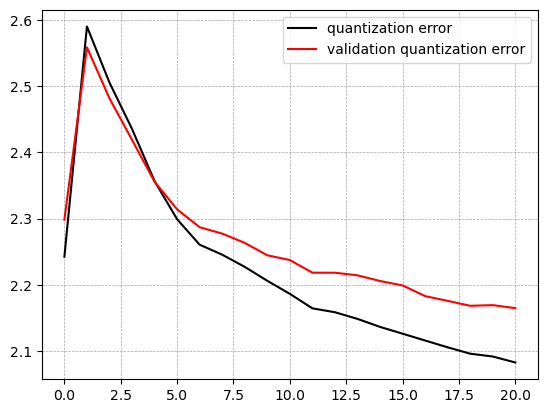

In [16]:
plt.plot(q_error, c='k', label='quantization error')
plt.plot(v_q_error, c="r", label="validation quantization error")
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
#plt.xticks([x for x in range(0,iters + 1) if x % 20 == 0])
plt.show()

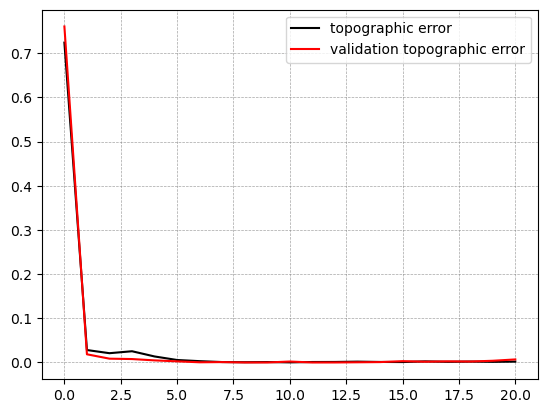

In [17]:
plt.plot(t_error, c='k', label='topographic error')
plt.plot(v_t_error, c="r", label="validation topographic error")
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
#plt.xticks([x for x in range(0,iters + 1) if x % 20 == 0])
plt.show()

In [18]:
#########################
###### Save Model ######
#########################
# import pickle
# model_version = 1
# # Assume 'som' is your trained MiniSom object
# with open(f"/ocean/projects/ees210011p/hdoubler/AOSC650/som_{som_grid_rows}x{som_grid_columns}_v{model_version}.p", 'wb') as outfile:
#     pickle.dump(som, outfile)

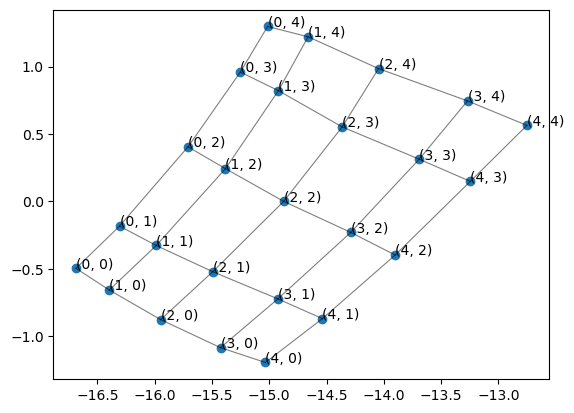

In [15]:
cur_shp = som.get_weights().shape
x = som.get_weights().reshape(cur_shp[0]*cur_shp[0], cur_shp[-1])
sammon_map, e = sammon(x, 2, display=0)

fig, ax = plt.subplots()

# Build a lookup from grid coord -> sammon position
coord_to_idx = {key: i for i, key in enumerate(som_keys)}
# Draw edges between adjacent nodes
for i, key in enumerate(som_keys):
    r, c = key
    for neighbor in [(r+1, c), (r, c+1)]:  # only right and down to avoid duplicates
        if neighbor in coord_to_idx:
            j = coord_to_idx[neighbor]
            ax.plot(
                [sammon_map[i, 0], sammon_map[j, 0]],
                [sammon_map[i, 1], sammon_map[j, 1]],
                'k-', linewidth=0.8, alpha=0.5
            )

ax.scatter(sammon_map[:, 0], sammon_map[:, 1])

for i, key in enumerate(som_keys):
    ax.annotate(key, (sammon_map[i, 0], sammon_map[i, 1]))

plt.show()

In [9]:
#################################
###### Open Previous Model ######
#################################
import pickle
file = "som_5x5_v1.p"
with open(f'/ocean/projects/ees210011p/hdoubler/AOSC650/{file}', 'rb') as infile:
    som = pickle.load(infile)

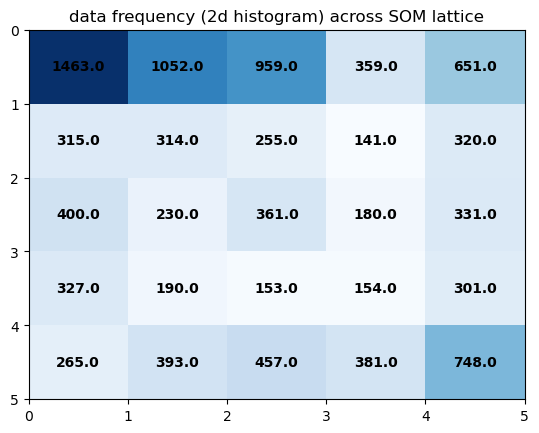

In [12]:
plt.figure()
frequencies = som.activation_response(samples)
plt.pcolormesh(frequencies, cmap='Blues')
plt.title("data frequency (2d histogram) across SOM lattice", fontsize=12)
plt.ylim(som_grid_rows, 0)  # flip the y axis to be the same as composite map axes later

# Add values to each cell
for i in range(frequencies.shape[0]):
    for j in range(frequencies.shape[1]):
        # Center coordinates: (x_edge + next_x_edge) / 2
        cx = (j + j+1) / 2
        cy = (i + i+1) / 2
        
        # Add text label with contrasting color
        plt.text(cx, cy, str(frequencies[i, j]), color='black', 
                ha='center', va='center', fontweight='bold')

plt.show()

In [17]:
# grabbing indices from SOM

# create an empty dictionary using the rows and columns of SOM
keys = [i for i in product(range(som_grid_rows), range(som_grid_columns))]
winmap = {key: [] for key in keys}

# grab the indices for the data within the SOM lattice
for i, x in enumerate(samples):
    winmap[som.winner(x)].append(i)
som_keys = list(winmap.keys())

# Permutation/Ablation Tests

In [18]:
#################################
###### Coarsen Elev for Mask ######
#################################

pr_lon2d, pr_lat2d = np.meshgrid(pr_subset["lon"], pr_subset["lat"])
elev_ds = xr.open_dataset('/ocean/projects/ees210011p/hdoubler/AOSC650/elevation.nc')
elev_subset = elev_ds.sel(lat=slice(np.max(pr_lat2d), np.min(pr_lat2d)), lon=slice(np.min(pr_lon2d), np.max(pr_lon2d)))
elev_ds.close()

# Target dimensions
target_lat = 22
target_lon = 28

# Calculate window sizes
lon_window = elev_subset.dims['lon'] // target_lon  # 11
lat_window = elev_subset.dims['lat'] // target_lat  # 11

# Trim elev_subset so dimensions are evenly divisible
lon_trim = elev_subset.dims['lon'] % target_lon  # leftover pixels
lat_trim = elev_subset.dims['lat'] % target_lat

elev_trimmed = elev_subset.isel(
    lon=slice(0, elev_subset.dims['lon'] - lon_trim),
    lat=slice(0, elev_subset.dims['lat'] - lat_trim)
)

# Coarsen by taking the mean (or use .max() / .min() for elevation if preferred)
elev_coarse = elev_trimmed.coarsen(
    lon=lon_window,
    lat=lat_window,
    boundary='trim'
).mean()

# Re-index to pr_subset's exact coordinates to align them perfectly
elev_coarse = elev_coarse.assign_coords(
    lon=pr_subset.lon.values,
    lat=pr_subset.lat.values
)

/var/tmp/ipykernel_15931/1037623755.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  lon_window = elev_subset.dims['lon'] // target_lon  # 11
/var/tmp/ipykernel_15931/1037623755.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  lat_window = elev_subset.dims['lat'] // target_lat  # 11
/var/tmp/ipykernel_15931/1037623755.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  lon_trim = el

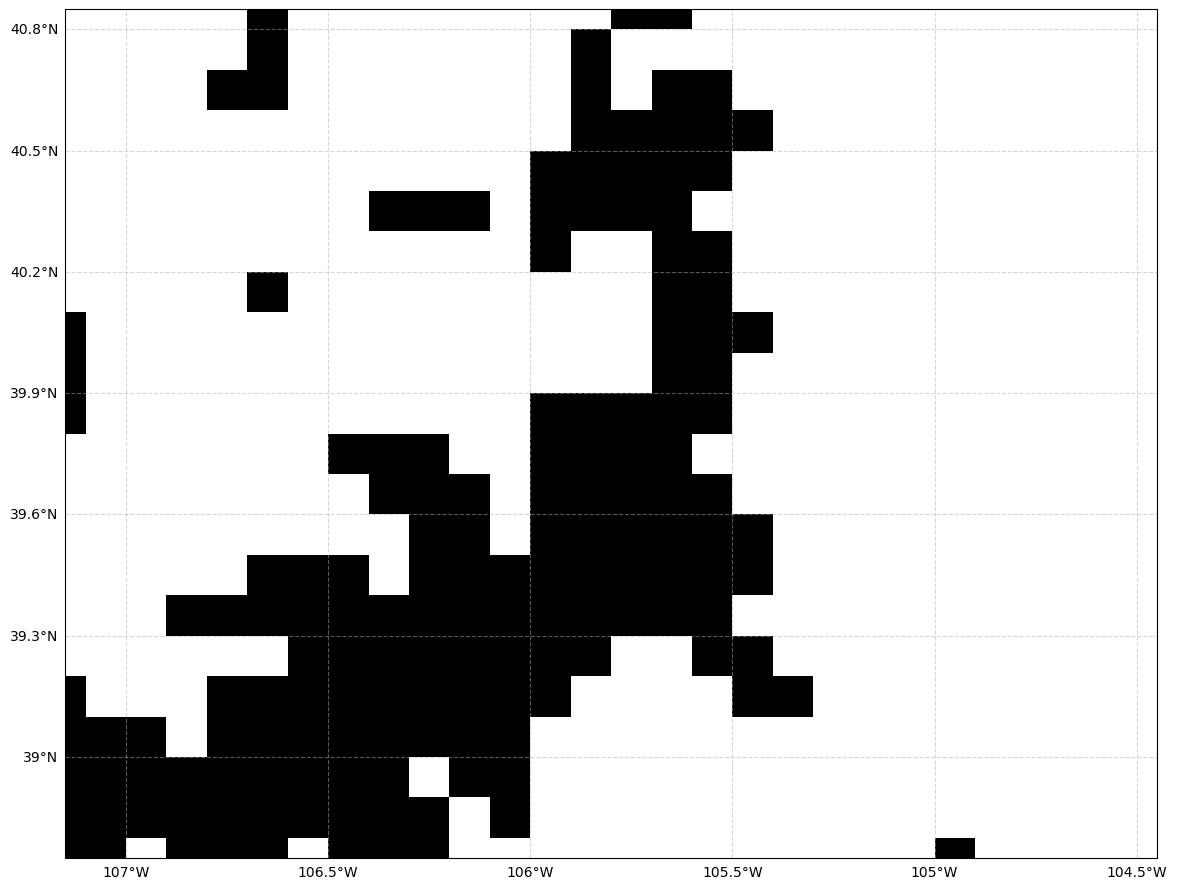

In [19]:
#######################################
######### Peak Elevation Mask #########
#######################################

MAX_HGT = 3000
elev_mask = elev_coarse["HGT"] < MAX_HGT

### APPLY MASK
mask_arr = np.array(elev_mask).reshape(616)

### SHOW MASK
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

lon2d, lat2d = np.meshgrid(elev_coarse["lon"], elev_coarse["lat"])
elev_mesh = ax.pcolormesh(
    lon2d, lat2d, elev_mask, 
    transform=ccrs.PlateCarree(), 
    cmap="binary_r",
    # vmin=mesh_min, vmax=mesh_max
  )

ax.set_extent([np.min(pr_lon2d), np.max(pr_lon2d), np.min(pr_lat2d), np.max(pr_lat2d)], ccrs.PlateCarree())

ax.margins(x=0, y=0)

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# plot the figure containing all plots
#plt.colorbar(elev_mesh, label="Elevation (m)", fraction=0.05, pad=0.02, shrink=0.5)
plt.tight_layout()
plt.show()

In [17]:
################################################
######### Permutation/Ablation Tests #########
################################################

######################
focus_set = samples
######################

gp_lossarray = np.zeros((som_grid_rows, som_grid_columns))
pr_lossarray = np.zeros((som_grid_rows, som_grid_columns))
pr_ablation_lossarray = np.zeros((som_grid_rows, som_grid_columns))

for key in som_keys:
    # make shuffled sets
    shuffled_gp_samples = shuffle_first_x(focus_set, winmap[key], 600)
    shuffled_pr_samples = shuffle_last_x(focus_set, winmap[key], 600)
    ablated_pr_samples = mask_last_x(focus_set, winmap[key], 600, mask_arr)
    
    for s in winmap[key]:
        new_gp_win = som.winner(shuffled_gp_samples[s])
        new_pr_win = som.winner(shuffled_pr_samples[s])
        new_pr_abl_win = som.winner(ablated_pr_samples[s])
        
        if new_gp_win != key:
            gp_lossarray[key] += 1
        if new_pr_win != key:
            pr_lossarray[key] += 1
        if new_pr_abl_win != key:
            pr_ablation_lossarray[key] += 1

gp_lossarray = gp_lossarray / frequencies
pr_lossarray = pr_lossarray / frequencies
pr_ablation_lossarray = pr_ablation_lossarray / frequencies

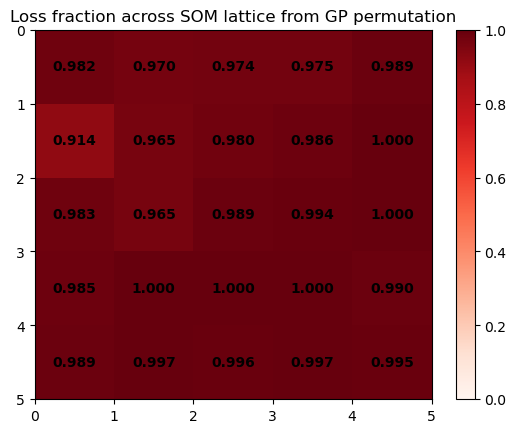

In [32]:
###########################################
######### GP Permutation Loss Map #########
###########################################
plt.figure()
plt.pcolormesh(gp_lossarray, cmap='Reds', vmax=1.0, vmin=0.0)
plt.colorbar()
plt.title("Loss fraction across SOM lattice from GP permutation", fontsize=12)
plt.ylim(som_grid_rows, 0)  # flip the y axis to be the same as composite map axes later

# Add values to each cell
for i in range(gp_lossarray.shape[0]):
    for j in range(gp_lossarray.shape[1]):
        # Center coordinates: (x_edge + next_x_edge) / 2
        cx = (j + j+1) / 2
        cy = (i + i+1) / 2
        
        # Add text label with contrasting color
        plt.text(cx, cy, f"{gp_lossarray[i, j]:.3f}", color='black', 
                ha='center', va='center', fontweight='bold')

plt.show()

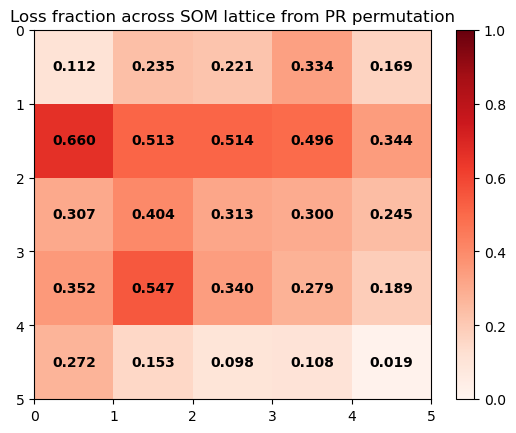

In [34]:
###########################################
######### PR Permutation Loss Map #########
###########################################

plt.figure()
plt.pcolormesh(pr_lossarray, cmap='Reds', vmax=1.0, vmin=0.0)
plt.colorbar()
plt.title("Loss fraction across SOM lattice from PR permutation", fontsize=12)
plt.ylim(som_grid_rows, 0)  # flip the y axis to be the same as composite map axes later

# Add values to each cell
for i in range(pr_lossarray.shape[0]):
    for j in range(pr_lossarray.shape[1]):
        # Center coordinates: (x_edge + next_x_edge) / 2
        cx = (j + j+1) / 2
        cy = (i + i+1) / 2
        
        # Add text label with contrasting color
        plt.text(cx, cy, f"{pr_lossarray[i, j]:.3f}", color='black', 
                ha='center', va='center', fontweight='bold')

plt.show()

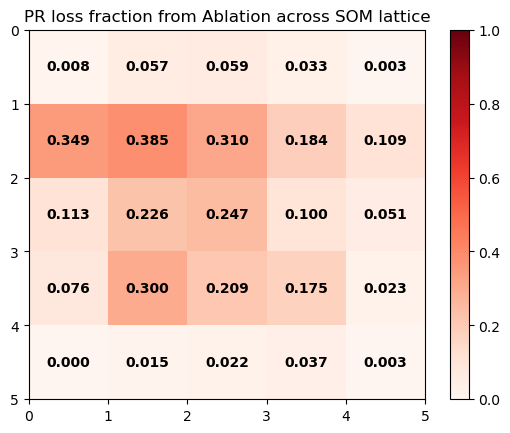

In [19]:
###########################################################
######### PR Mountaiin Peak Ablation Loss Map #########
###########################################################

plt.figure()
plt.pcolormesh(pr_ablation_lossarray, cmap='Reds', vmax=1.0, vmin=0.0)
plt.colorbar()
plt.title("PR loss fraction from Ablation across SOM lattice", fontsize=12)
plt.ylim(som_grid_rows, 0)  # flip the y axis to be the same as composite map axes later

# Add values to each cell
for i in range(pr_ablation_lossarray.shape[0]):
    for j in range(pr_ablation_lossarray.shape[1]):
        # Center coordinates: (x_edge + next_x_edge) / 2
        cx = (j + j+1) / 2
        cy = (i + i+1) / 2
        
        # Add text label with contrasting color
        plt.text(cx, cy, f"{pr_ablation_lossarray[i, j]:.3f}", color='black', 
                ha='center', va='center', fontweight='bold')

plt.show()

In [28]:
#######################################
######### GP LOSS FRACTION MAP #########
#######################################
lats = gp_subset.latitude.values
lons = gp_subset.longitude.values

n_lat = len(lats)
n_lon = len(lons)
gp_loss_maps = {key: np.zeros((n_lat, n_lon)) for key in keys}

######################
focus_set = samples
######################

mask_size = 3

for k, key in enumerate(keys):
    print(f"Working on {key}...")
    for ci in range(n_lat):       # center lat index
        for cj in range(n_lon):   # center lon index
            
            # Build base mask of ones
            mask = np.ones((n_lat, n_lon), dtype=float)
    
            half = mask_size // 2
            
            # Compute masked region bounds (clamped to domain edges)
            lat_lo = max(ci - half, 0)
            lat_hi = min(ci + half + 1, n_lat)
            lon_lo = max(cj - half, 0)
            lon_hi = min(cj + half + 1, n_lon)
            
            # Apply mask (0 = masked region)
            mask[lat_lo:lat_hi, lon_lo:lon_hi] = 0.0
            mask_arr = mask.reshape(600)
            
            ablated_gp_samples = mask_first_x(focus_set, winmap[key], 600, mask_arr)
    
            loss_ct = 0
            for s in winmap[key]:
                new_win = som.winner(ablated_gp_samples[s])
        
                if new_win != key:
                    loss_ct += 1
                    
            gp_loss_maps[key][ci, cj] = loss_ct / len(winmap[key])

Working on (0, 0)...
Working on (0, 1)...
Working on (0, 2)...
Working on (0, 3)...
Working on (0, 4)...
Working on (1, 0)...
Working on (1, 1)...
Working on (1, 2)...
Working on (1, 3)...
Working on (1, 4)...
Working on (2, 0)...
Working on (2, 1)...
Working on (2, 2)...
Working on (2, 3)...
Working on (2, 4)...
Working on (3, 0)...
Working on (3, 1)...
Working on (3, 2)...
Working on (3, 3)...
Working on (3, 4)...
Working on (4, 0)...
Working on (4, 1)...
Working on (4, 2)...
Working on (4, 3)...
Working on (4, 4)...


5800.786899364968
making plots ...
Map 0: parsing data ...
Map 0: adding map features ...

Map 1: parsing data ...
Map 1: adding map features ...

Map 2: parsing data ...
Map 2: adding map features ...

Map 3: parsing data ...
Map 3: adding map features ...

Map 4: parsing data ...
Map 4: adding map features ...

Map 5: parsing data ...
Map 5: adding map features ...

Map 6: parsing data ...
Map 6: adding map features ...

Map 7: parsing data ...
Map 7: adding map features ...

Map 8: parsing data ...
Map 8: adding map features ...

Map 9: parsing data ...
Map 9: adding map features ...

Map 10: parsing data ...
Map 10: adding map features ...

Map 11: parsing data ...
Map 11: adding map features ...

Map 12: parsing data ...
Map 12: adding map features ...

Map 13: parsing data ...
Map 13: adding map features ...

Map 14: parsing data ...
Map 14: adding map features ...

Map 15: parsing data ...
Map 15: adding map features ...

Map 16: parsing data ...
Map 16: adding map features ...


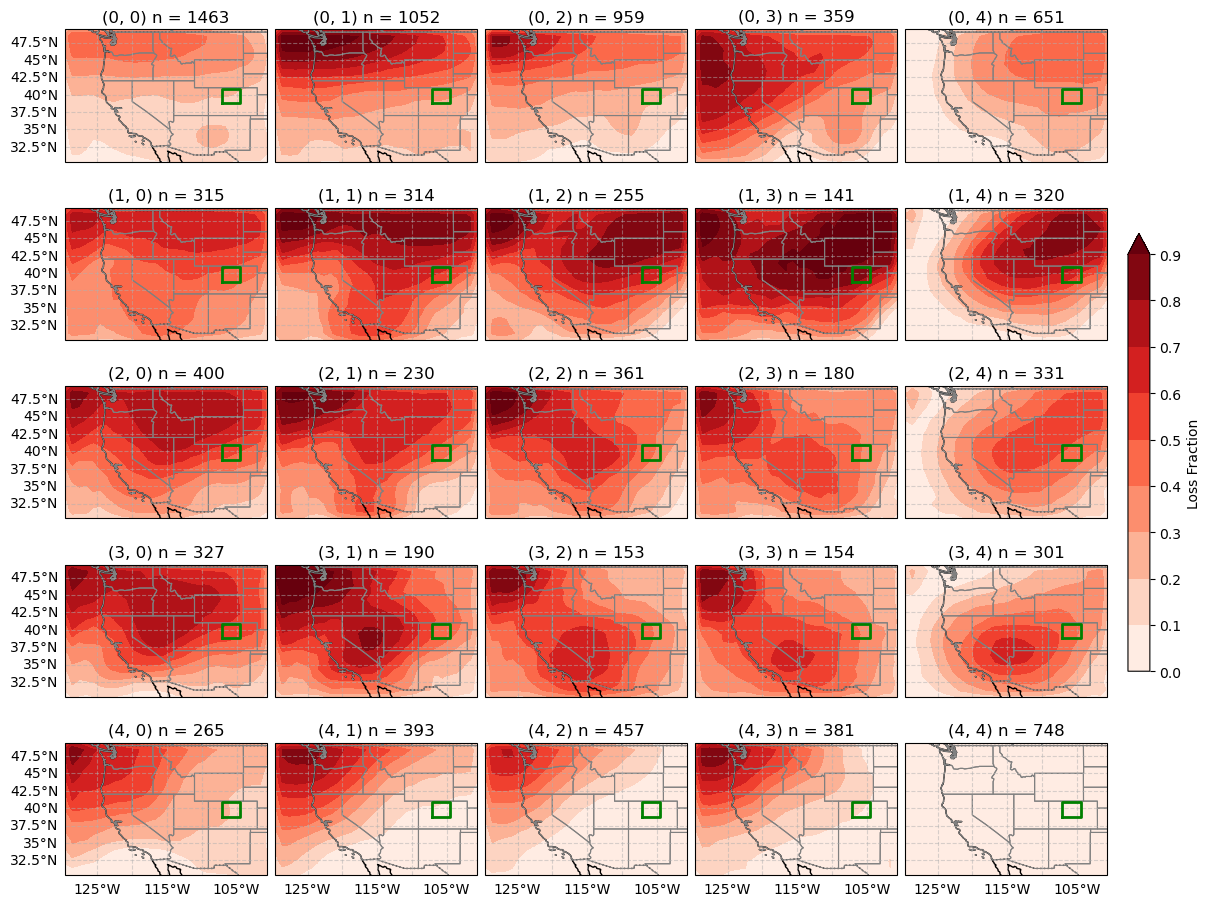

In [31]:
###########################################
######### GP LOSS FRACTION MAP PLOT #########
###########################################

# view all SOM composite maps
# (this cell takes a few minutes to run, especially if SOM lattice is large)
abs_max = np.max(np.abs(gp_subset.values))
print(abs_max)

# grab values for grid
lon2d, lat2d = np.meshgrid(gp_subset["longitude"], gp_subset["latitude"])

pr_box = bounding_box(pr_lat2d, pr_lon2d, "MSWEP pr", "green")

# create a figure using the same dimensions as SOM
fig, axs = plt.subplots(
    som_grid_rows, som_grid_columns,
    figsize=(12, 9),
    constrained_layout=True,
    subplot_kw={
        'projection': ccrs.PlateCarree()
    }
)

print("making plots ...")
# (1) loop through the SOM neurons,
# (2) grab data samples using SOM indices,
# (3) compute the mean for each SOM neuron, plot each
for map_num in range(len(som_keys)):
    ax = axs[som_keys[map_num][0], som_keys[map_num][1]]
    
    print(f"Map {map_num}: parsing data ...")
    # the data
    temp_data = gp_loss_maps[som_keys[map_num]]

    # plot
    fr_levels = np.arange(0, 1, 0.1)
    cs = ax.contourf(lon2d, lat2d, temp_data, 
                transform=ccrs.PlateCarree(), 
                levels = fr_levels, 
                cmap="Reds", 
                extend="max"
                )

    
    # title
    ax.set_title(f"{som_keys[map_num]} n = {int(frequencies.flatten()[map_num])}", fontsize=12)

    # add plot stuff
    ax.margins(x=0, y=0)

    print(f"Map {map_num}: adding map features ...")
    # Add features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.8)

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = som_keys[map_num][1] == 0
    gl.bottom_labels = som_keys[map_num][0] == som_grid_rows - 1
    
    box_lat, box_lon = pr_box.get_box_edges()
    # Plot bounding box
    ax.plot(box_lon, box_lat, color=pr_box.color, linewidth=2, label=pr_box.label)
    
    print()
# plot the figure containing all plots
plt.colorbar(cs,          
        ax=axs, 
        orientation="vertical", 
        fraction=0.05, pad=0.02, shrink=0.5,
        label="Loss Fraction"
    )
plt.show()

In [28]:
#######################################
######### PR LOSS FRACTION MAP #########
#######################################

lats = pr_subset.lat.values
lons = pr_subset.lon.values

n_lat = len(lats)
n_lon = len(lons)
pr_loss_maps = {key: np.zeros((n_lat, n_lon)) for key in keys}

######################
focus_set = samples
######################

mask_size = 3

for k, key in enumerate(keys):
    print(f"Working on {key}...")
    for ci in range(n_lat):       # center lat index
        for cj in range(n_lon):   # center lon index
            
            # Build base mask of ones
            mask = np.ones((n_lat, n_lon), dtype=float)
    
            half = mask_size // 2
            
            # Compute masked region bounds (clamped to domain edges)
            lat_lo = max(ci - half, 0)
            lat_hi = min(ci + half + 1, n_lat)
            lon_lo = max(cj - half, 0)
            lon_hi = min(cj + half + 1, n_lon)
            
            # Apply mask (0 = masked region)
            mask[lat_lo:lat_hi, lon_lo:lon_hi] = 0.0
            mask_arr = mask.reshape(616)
            
            ablated_pr_samples = mask_last_x(focus_set, winmap[key], 600, mask_arr)
    
            loss_ct = 0
            for s in winmap[key]:
                new_win = som.winner(ablated_pr_samples[s])
        
                if new_win != key:
                    loss_ct += 1
                    
            pr_loss_maps[key][ci, cj] = loss_ct / len(winmap[key])

Working on (0, 0)...
Working on (0, 1)...
Working on (0, 2)...
Working on (0, 3)...
Working on (0, 4)...
Working on (1, 0)...
Working on (1, 1)...
Working on (1, 2)...
Working on (1, 3)...
Working on (1, 4)...
Working on (2, 0)...
Working on (2, 1)...
Working on (2, 2)...
Working on (2, 3)...
Working on (2, 4)...
Working on (3, 0)...
Working on (3, 1)...
Working on (3, 2)...
Working on (3, 3)...
Working on (3, 4)...
Working on (4, 0)...
Working on (4, 1)...
Working on (4, 2)...
Working on (4, 3)...
Working on (4, 4)...


making plots ...
Map 0: parsing data ...

Map 1: parsing data ...

Map 2: parsing data ...

Map 3: parsing data ...

Map 4: parsing data ...

Map 5: parsing data ...

Map 6: parsing data ...

Map 7: parsing data ...

Map 8: parsing data ...

Map 9: parsing data ...

Map 10: parsing data ...

Map 11: parsing data ...

Map 12: parsing data ...

Map 13: parsing data ...

Map 14: parsing data ...

Map 15: parsing data ...

Map 16: parsing data ...

Map 17: parsing data ...

Map 18: parsing data ...

Map 19: parsing data ...

Map 20: parsing data ...

Map 21: parsing data ...

Map 22: parsing data ...

Map 23: parsing data ...

Map 24: parsing data ...



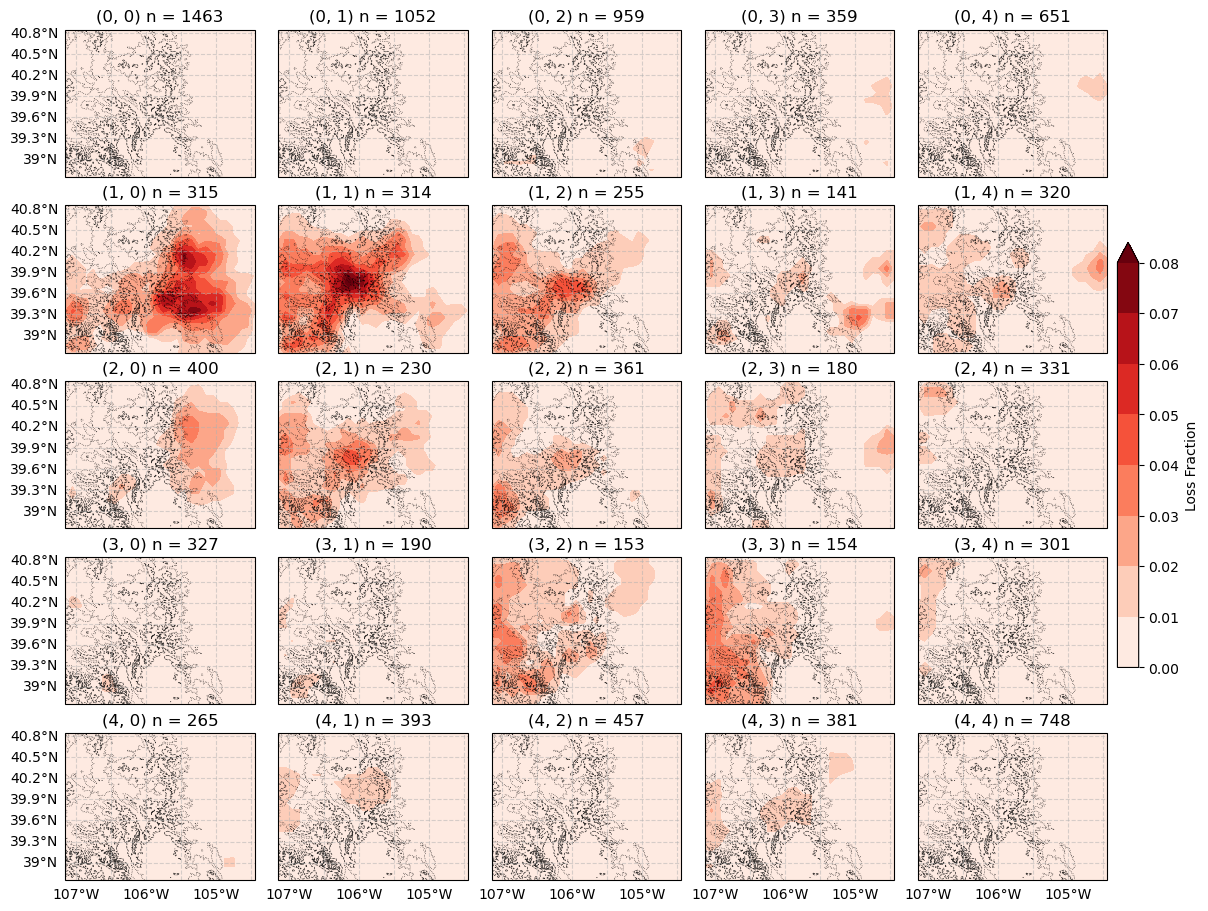

In [41]:
###########################################
######### PR LOSS FRACTION MAP PLOT #########
###########################################

# view all SOM composite maps
# (this cell takes a few minutes to run, especially if SOM lattice is large)

lon2d, lat2d = np.meshgrid(elev_coarse["lon"], elev_coarse["lat"])
# grab values for grid
elev_lon2d, elev_lat2d = np.meshgrid(elev_subset["lon"], elev_subset["lat"])

# create a figure using the same dimensions as SOM
fig, axs = plt.subplots(
    som_grid_rows, som_grid_columns,
    figsize=(12, 9),
    constrained_layout=True,
    subplot_kw={
        'projection': ccrs.PlateCarree()
    }
)

cbar_max = max(pr_loss_maps[key].max() for key in keys)

print("making plots ...")
# (1) loop through the SOM neurons,
# (2) grab data samples using SOM indices,
# (3) compute the mean for each SOM neuron, plot each
for map_num in range(len(som_keys)):
    ax = axs[som_keys[map_num][0], som_keys[map_num][1]]
    
    print(f"Map {map_num}: parsing data ...")

    ## NORMAL PRECIP ###
    # the data
    temp_data = pr_loss_maps[som_keys[map_num]]

    # plot
    fr_levels = np.arange(0, round(cbar_max,2), 0.01)
    cs = ax.contourf(lon2d, lat2d, temp_data, 
                transform=ccrs.PlateCarree(), 
                levels = fr_levels, 
                cmap="Reds", 
                extend="max"
                )

    elev_levels = [2600, 3200, 3800]
    elev_mesh = ax.contour(
        elev_lon2d, elev_lat2d, elev_subset["HGT"], 
        transform=ccrs.PlateCarree(), 
        colors="black", 
        linewidths=0.5,
        linestyles=["dotted", "dashed", "solid"],
        levels=elev_levels,
        alpha=0.8
      )

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = som_keys[map_num][1] == 0
    gl.bottom_labels = som_keys[map_num][0] == som_grid_rows - 1
    
    # title
    ax.set_title(f"{som_keys[map_num]} n = {int(frequencies.flatten()[map_num])}", fontsize=12)

    # add plot stuff
    ax.margins(x=0, y=0)

    # print(f"Map {map_num}: adding map features ...")
    # # Add features
    # ax.add_feature(cfeature.COASTLINE)
    # ax.add_feature(cfeature.BORDERS, linestyle=':')
    # ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.8)

    print()
# plot the figure containing all plots
plt.colorbar(cs, 
         ax=axs, 
         orientation="vertical", 
         fraction=0.05, pad=0.01, shrink=0.5,
         label="Loss Fraction"
        )
plt.show()

# Average Sample Plotting

5800.786899364968
making plots ...
Map 0: parsing data ...
Map 0: adding map features ...

Map 1: parsing data ...
Map 1: adding map features ...

Map 2: parsing data ...
Map 2: adding map features ...

Map 3: parsing data ...
Map 3: adding map features ...

Map 4: parsing data ...
Map 4: adding map features ...

Map 5: parsing data ...
Map 5: adding map features ...

Map 6: parsing data ...
Map 6: adding map features ...

Map 7: parsing data ...
Map 7: adding map features ...

Map 8: parsing data ...
Map 8: adding map features ...

Map 9: parsing data ...
Map 9: adding map features ...

Map 10: parsing data ...
Map 10: adding map features ...

Map 11: parsing data ...
Map 11: adding map features ...

Map 12: parsing data ...
Map 12: adding map features ...

Map 13: parsing data ...
Map 13: adding map features ...

Map 14: parsing data ...
Map 14: adding map features ...

Map 15: parsing data ...
Map 15: adding map features ...

Map 16: parsing data ...
Map 16: adding map features ...


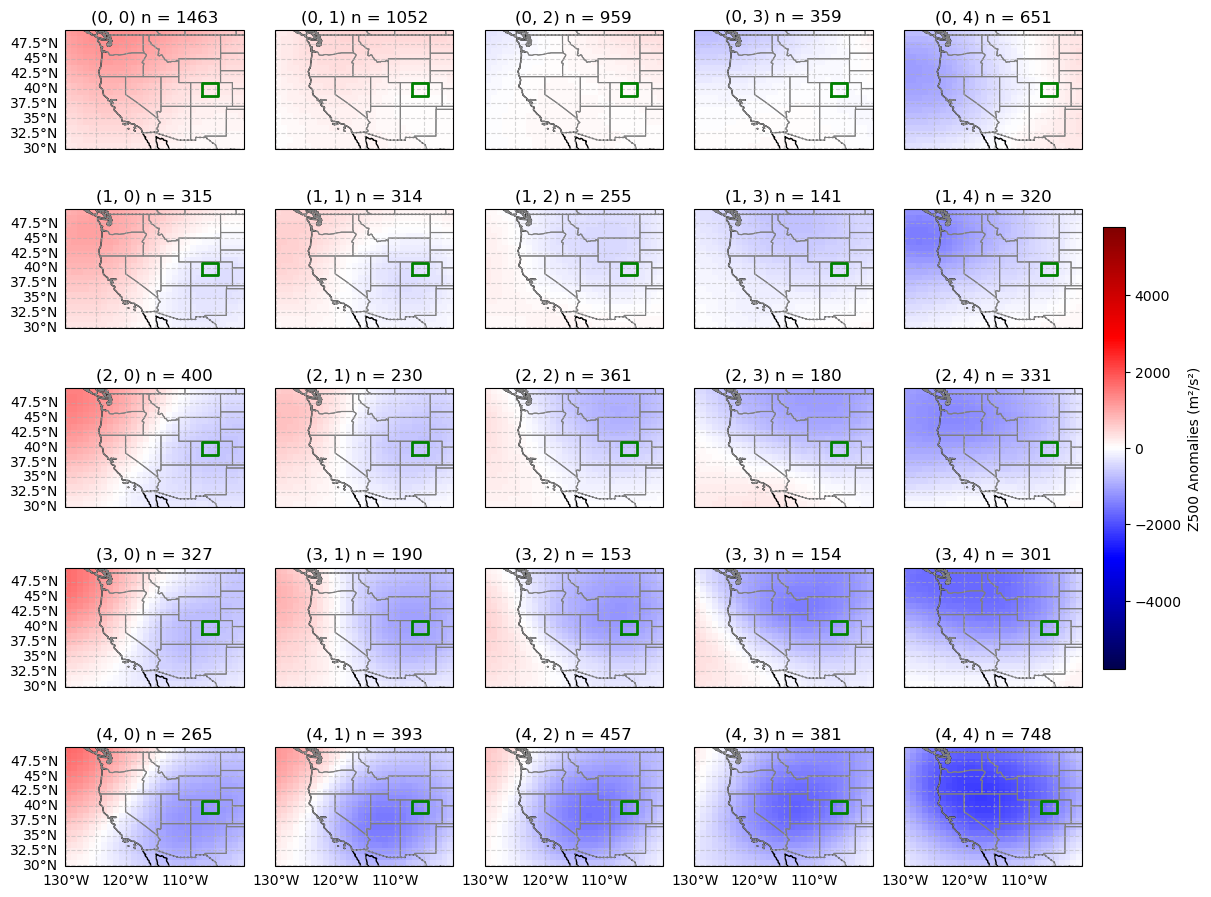

In [22]:
################################
######### AVG GP PLOT #########
################################

# view all SOM composite maps
# (this cell takes a few minutes to run, especially if SOM lattice is large)
abs_max = np.max(np.abs(gp_subset.values))
print(abs_max)

# grab values for grid
lon2d, lat2d = np.meshgrid(gp_subset["longitude"], gp_subset["latitude"])

pr_box = bounding_box(pr_lat2d, pr_lon2d, "MSWEP pr", "green")

# create a figure using the same dimensions as SOM
fig, axs = plt.subplots(
    som_grid_rows, som_grid_columns,
    figsize=(12, 9),
    constrained_layout=True,
    subplot_kw={
        'projection': ccrs.PlateCarree()
    }
)

print("making plots ...")
# (1) loop through the SOM neurons,
# (2) grab data samples using SOM indices,
# (3) compute the mean for each SOM neuron, plot each
for map_num in range(len(som_keys)):
    ax = axs[som_keys[map_num][0], som_keys[map_num][1]]
    
    print(f"Map {map_num}: parsing data ...")
    # the data
    temp_data = gp_subset[
        np.array(winmap[som_keys[map_num]])].mean(dim="time", skipna=True).values

    # plot
    cs = axs[som_keys[map_num][0], som_keys[map_num][1]].pcolormesh(
        lon2d, lat2d, temp_data, transform=ccrs.PlateCarree(), cmap="seismic", vmin=-1*abs_max, vmax=abs_max)

    # title
    ax.set_title(f"{som_keys[map_num]} n = {int(frequencies.flatten()[map_num])}", fontsize=12)

    # add plot stuff
    ax.margins(x=0, y=0)

    print(f"Map {map_num}: adding map features ...")
    # Add features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.8)

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = som_keys[map_num][1] == 0
    gl.bottom_labels = som_keys[map_num][0] == som_grid_rows - 1
    
    box_lat, box_lon = pr_box.get_box_edges()
    # Plot bounding box
    ax.plot(box_lon, box_lat, color=pr_box.color, linewidth=2, label=pr_box.label)
    
    print()
# plot the figure containing all plots
plt.colorbar(cs,          
        ax=axs, 
        orientation="vertical", 
        fraction=0.05, pad=0.02, shrink=0.5,
        label="Z500 Anomalies (m\u00b2/s\u00b2)"
    )
plt.show()

making plots ...
Map 0: parsing data ...

Map 1: parsing data ...

Map 2: parsing data ...

Map 3: parsing data ...

Map 4: parsing data ...

Map 5: parsing data ...

Map 6: parsing data ...

Map 7: parsing data ...

Map 8: parsing data ...

Map 9: parsing data ...

Map 10: parsing data ...

Map 11: parsing data ...

Map 12: parsing data ...

Map 13: parsing data ...

Map 14: parsing data ...

Map 15: parsing data ...

Map 16: parsing data ...

Map 17: parsing data ...

Map 18: parsing data ...

Map 19: parsing data ...

Map 20: parsing data ...

Map 21: parsing data ...

Map 22: parsing data ...

Map 23: parsing data ...

Map 24: parsing data ...



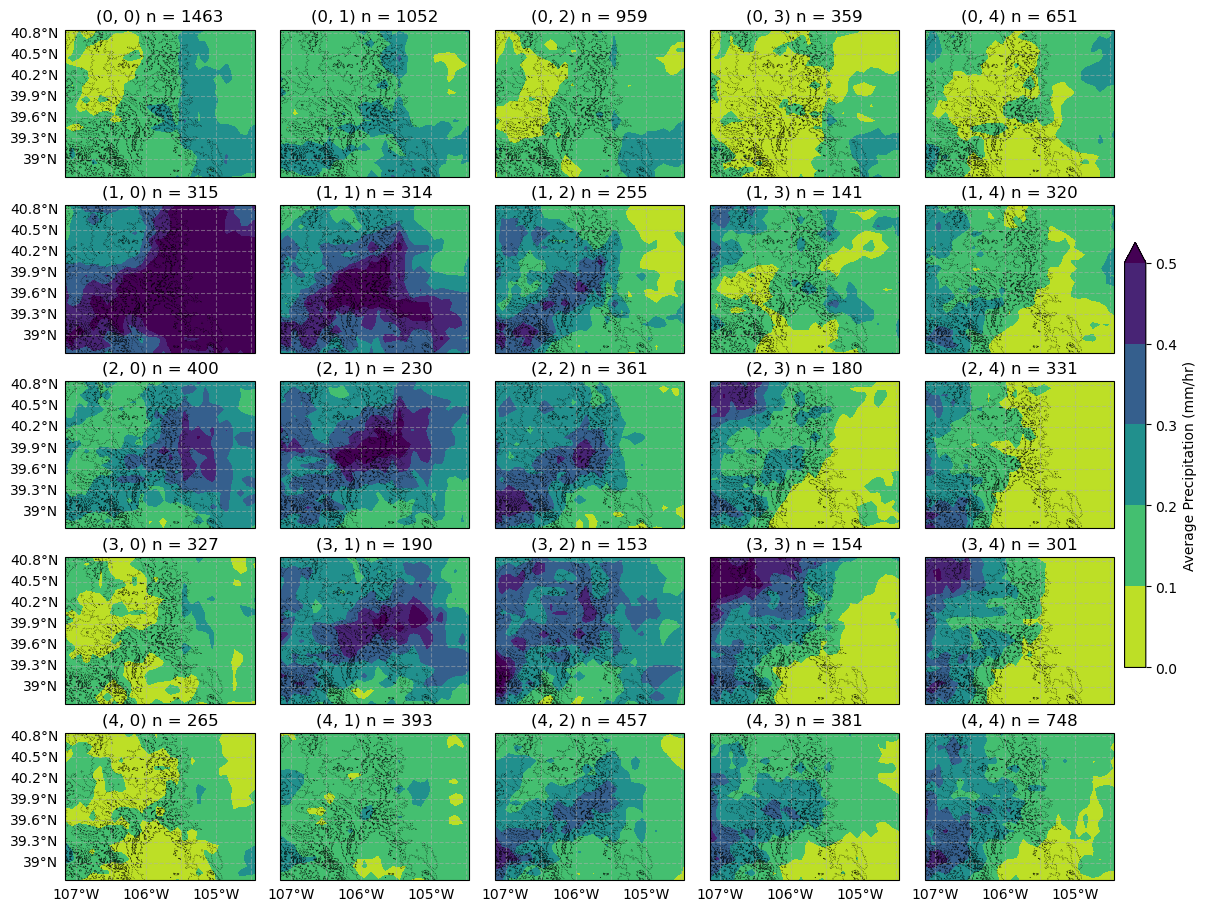

In [23]:
################################
######### AVG PR PLOT #########
################################

# view all SOM composite maps
# (this cell takes a few minutes to run, especially if SOM lattice is large)

# grab values for grid
elev_lon2d, elev_lat2d = np.meshgrid(elev_subset["lon"], elev_subset["lat"])

# create a figure using the same dimensions as SOM
fig, axs = plt.subplots(
    som_grid_rows, som_grid_columns,
    figsize=(12, 9),
    constrained_layout=True,
    subplot_kw={
        'projection': ccrs.PlateCarree()
    }
)

cbar_max = 1

print("making plots ...")
# (1) loop through the SOM neurons,
# (2) grab data samples using SOM indices,
# (3) compute the mean for each SOM neuron, plot each
for map_num in range(len(som_keys)):
    ax = axs[som_keys[map_num][0], som_keys[map_num][1]]
    
    print(f"Map {map_num}: parsing data ...")

    ## NORMAL PRECIP ###
    # the data
    temp_data = pr_subset[
        np.array(winmap[som_keys[map_num]])].mean(dim="time", skipna=True).values

    # plot
    pr_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    cs = ax.contourf(pr_lon2d, pr_lat2d, temp_data, 
                transform=ccrs.PlateCarree(), 
                levels = pr_levels, 
                cmap="viridis_r", 
                extend="max")

    elev_levels = [2600, 3200, 3800]
    elev_mesh = ax.contour(
        elev_lon2d, elev_lat2d, elev_subset["HGT"], 
        transform=ccrs.PlateCarree(), 
        colors="black", 
        linewidths=0.5,
        linestyles=["dotted", "dashed", "solid"],
        levels=elev_levels,
        alpha=0.8
      )

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = som_keys[map_num][1] == 0
    gl.bottom_labels = som_keys[map_num][0] == som_grid_rows - 1
    
    # title
    ax.set_title(f"{som_keys[map_num]} n = {int(frequencies.flatten()[map_num])}", fontsize=12)

    # add plot stuff
    ax.margins(x=0, y=0)

    # print(f"Map {map_num}: adding map features ...")
    # # Add features
    # ax.add_feature(cfeature.COASTLINE)
    # ax.add_feature(cfeature.BORDERS, linestyle=':')
    # ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.8)

    print()
# plot the figure containing all plots
plt.colorbar(cs, 
         ax=axs, 
         orientation="vertical", 
         fraction=0.05, pad=0.01, shrink=0.5,
         label="Average Precipitation (mm/hr)"
        )
plt.show()

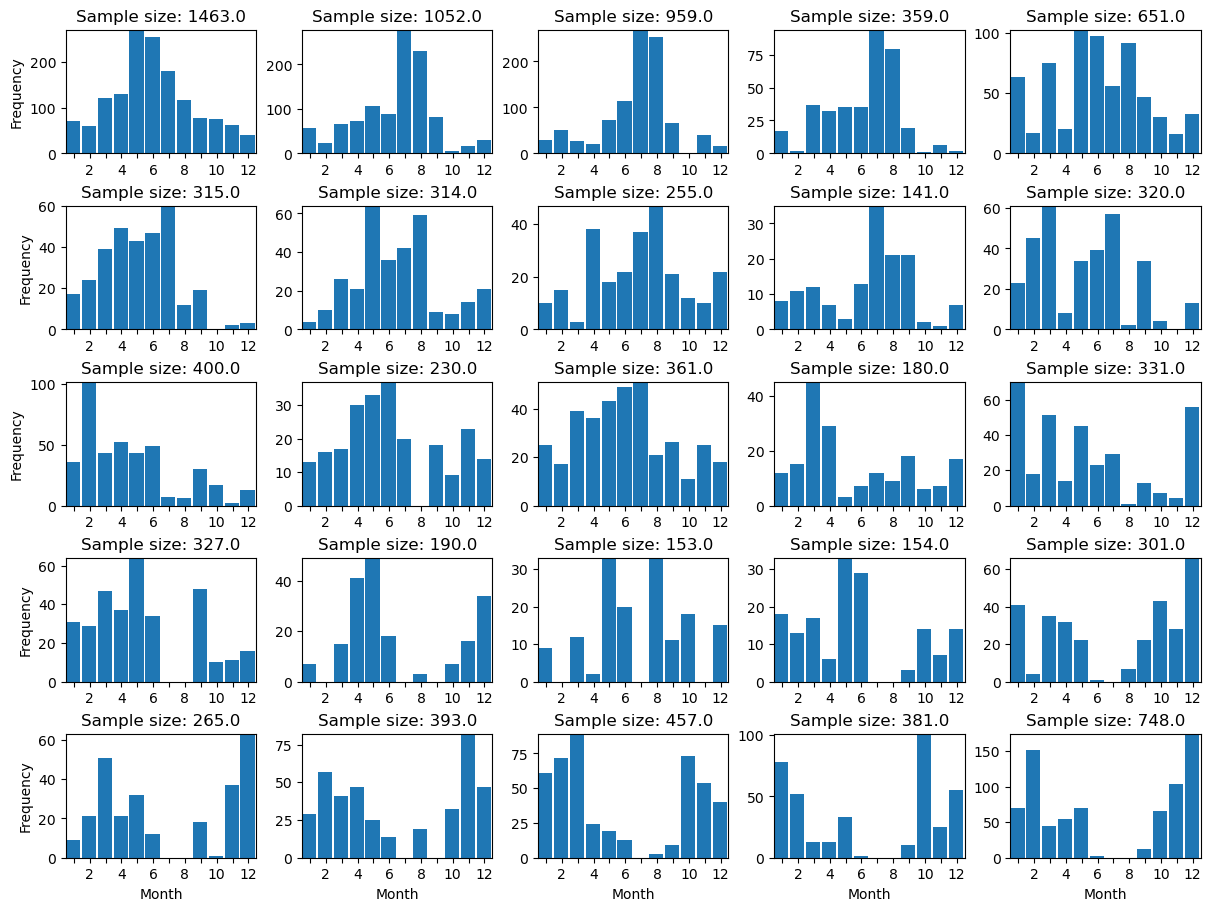

In [37]:
################################
######### AVG Month Hist #########
################################

months = filtered_df.index.month

# create a figure using the same dimensions as SOM
fig, axs = plt.subplots(
    som_grid_rows, som_grid_columns,
    figsize=(12, 9),
    constrained_layout=True
)

# (1) loop through the SOM neurons,
# (2) grab data samples using SOM indices,
# (3) compute the sum of another variable at each SOM neuron, plot each
for map_num in range(len(som_keys)):

    ax = axs[som_keys[map_num][0], som_keys[map_num][1]]
    
    # the data
    temp_data = months[np.array(winmap[som_keys[map_num]])]

    # plot
    counts, edges, patches = ax.hist(temp_data, bins=12, range=(1,13), width=0.9)
    if som_keys[map_num][1] == 0:
        ax.set_ylabel("Frequency")
    if som_keys[map_num][0] == som_grid_rows - 1:
        ax.set_xlabel("Month")
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    ax.set_xticks(bin_centers, labels=[l if l % 2 == 0 else "" for l in range(1,13)])
    
    # title
    ax.set_title(f"Sample size: {frequencies.flatten()[map_num]}", fontsize=12)

    # add plot stuff
    ax.margins(x=0, y=0)

# plot the figure containing all plots
#plt.tight_layout()
plt.show()

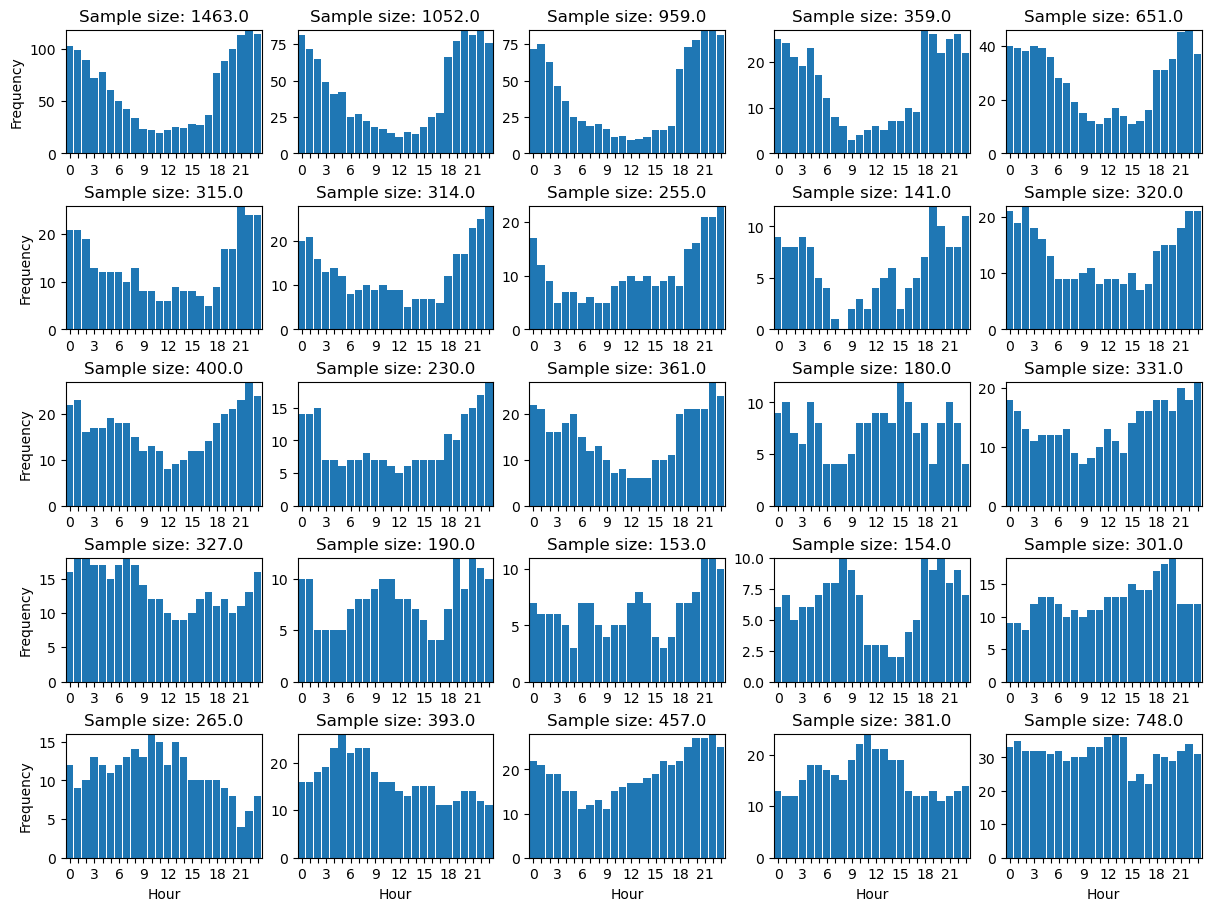

In [38]:
################################
######### AVG Hour Hist #########
################################

hours = filtered_df.index.hour

# create a figure using the same dimensions as SOM
fig, axs = plt.subplots(
    som_grid_rows, som_grid_columns,
    figsize=(12, 9),
    constrained_layout=True
)

# (1) loop through the SOM neurons,
# (2) grab data samples using SOM indices,
# (3) compute the sum of another variable at each SOM neuron, plot each
for map_num in range(len(som_keys)):

    ax = axs[som_keys[map_num][0], som_keys[map_num][1]]
    
    # the data
    temp_data = hours[np.array(winmap[som_keys[map_num]])]

    # plot
    counts, edges, patches = ax.hist(temp_data, bins=24, range=(0,24), width=0.9)
    if som_keys[map_num][1] == 0:
        ax.set_ylabel("Frequency")
    if som_keys[map_num][0] == som_grid_rows - 1:
        ax.set_xlabel("Hour")
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    ax.set_xticks(bin_centers, labels=[l if l % 3 == 0 else "" for l in range(0,24)])
    
    # title
    ax.set_title(f"Sample size: {frequencies.flatten()[map_num]}", fontsize=12)

    # add plot stuff
    ax.margins(x=0, y=0)

# plot the figure containing all plots
#plt.tight_layout()
plt.show()

# MISC

2021-01-16 11:00:00


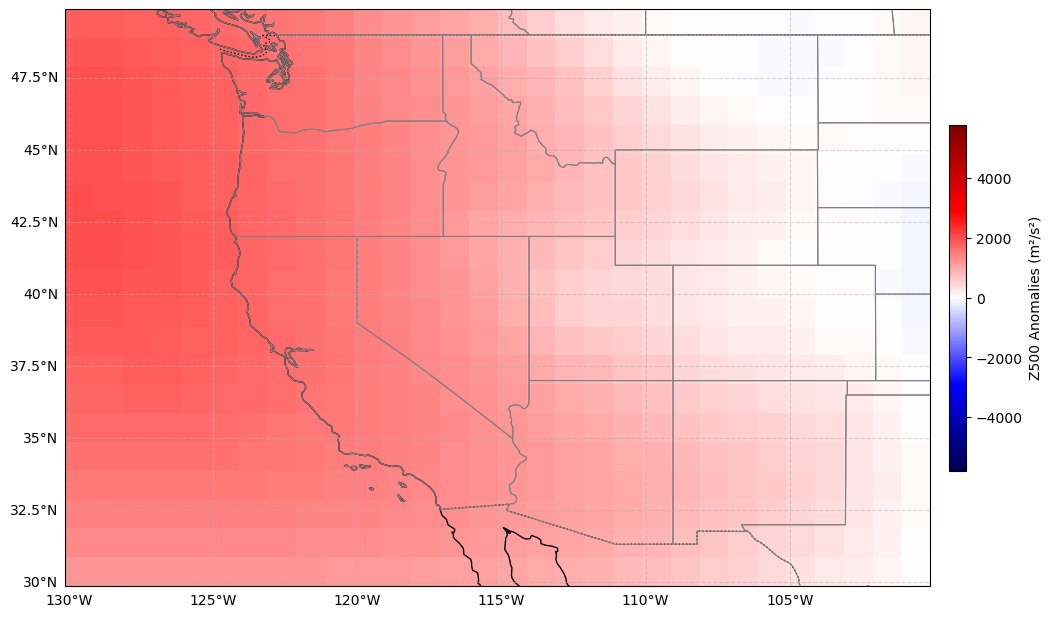

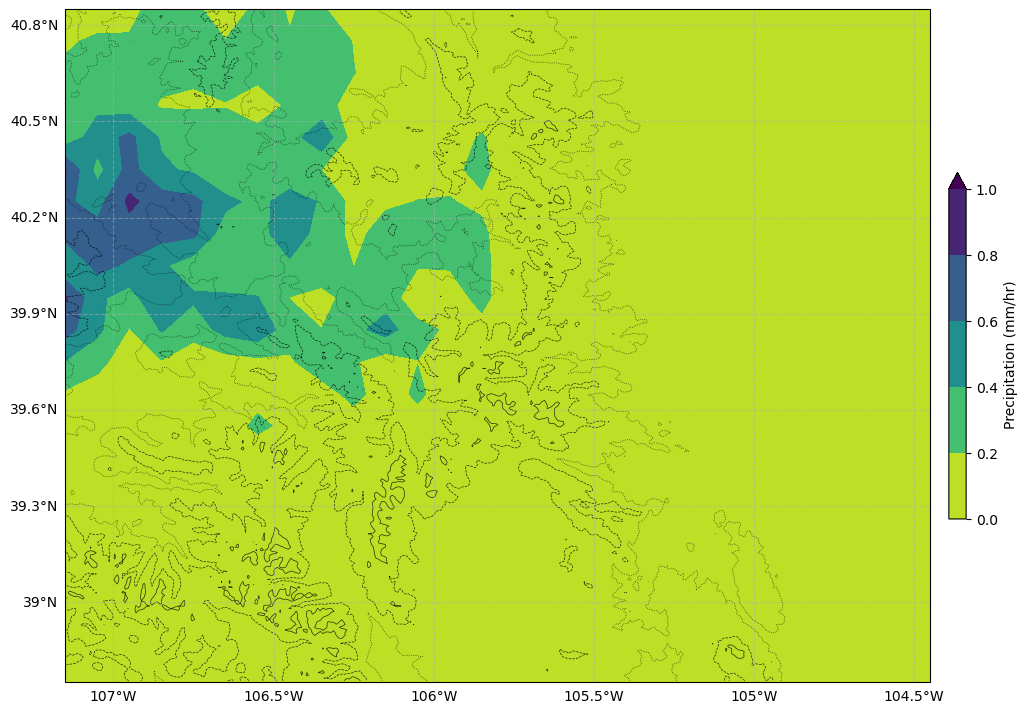

In [39]:
###############################################
######### Plot A GP and PR Sample Map #########
###############################################

subset_index = 4030

print(filtered_df.index[subset_index])

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

lon2d, lat2d = np.meshgrid(gp_subset["longitude"], gp_subset["latitude"])
elev_lon2d, elev_lat2d = np.meshgrid(elev_subset["lon"], elev_subset["lat"])

pr_box = bounding_box(pr_lat2d, pr_lon2d, "MSWEP pr", "green")

# the data
temp_data = gp_subset[subset_index].values

# plot
cs = ax.pcolormesh(lon2d, lat2d, temp_data, transform=ccrs.PlateCarree(), cmap="seismic", vmin=-1*abs_max, vmax=abs_max)

# add plot stuff
ax.margins(x=0, y=0)

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.8)

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# box_lat, box_lon = pr_box.get_box_edges()
# # Plot bounding box
# ax.plot(box_lon, box_lat, color=pr_box.color, linewidth=2, label=pr_box.label)

plt.colorbar(cs,          
        ax=ax, 
        orientation="vertical", 
        fraction=0.05, pad=0.02, shrink=0.5,
        label="Z500 Anomalies (m\u00b2/s\u00b2)"
    )
plt.show()

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

## NORMAL PRECIP ###
# the data
temp_data = pr_subset[subset_index].values

# plot
pr_levels = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
cs = ax.contourf(pr_lon2d, pr_lat2d, temp_data, 
            transform=ccrs.PlateCarree(), 
            levels = pr_levels, 
            cmap="viridis_r", 
            extend="max")

elev_levels = [2600, 3200, 3800]
elev_mesh = ax.contour(
    elev_lon2d, elev_lat2d, elev_subset["HGT"], 
    transform=ccrs.PlateCarree(), 
    colors="black", 
    linewidths=0.5,
    linestyles=["dotted", "dashed", "solid"],
    levels=elev_levels,
    alpha=0.8
  )

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# add plot stuff
ax.margins(x=0, y=0)

plt.colorbar(cs,          
        ax=ax, 
        orientation="vertical", 
        fraction=0.05, pad=0.02, shrink=0.5,
        label="Precipitation (mm/hr)"
    )
plt.show()

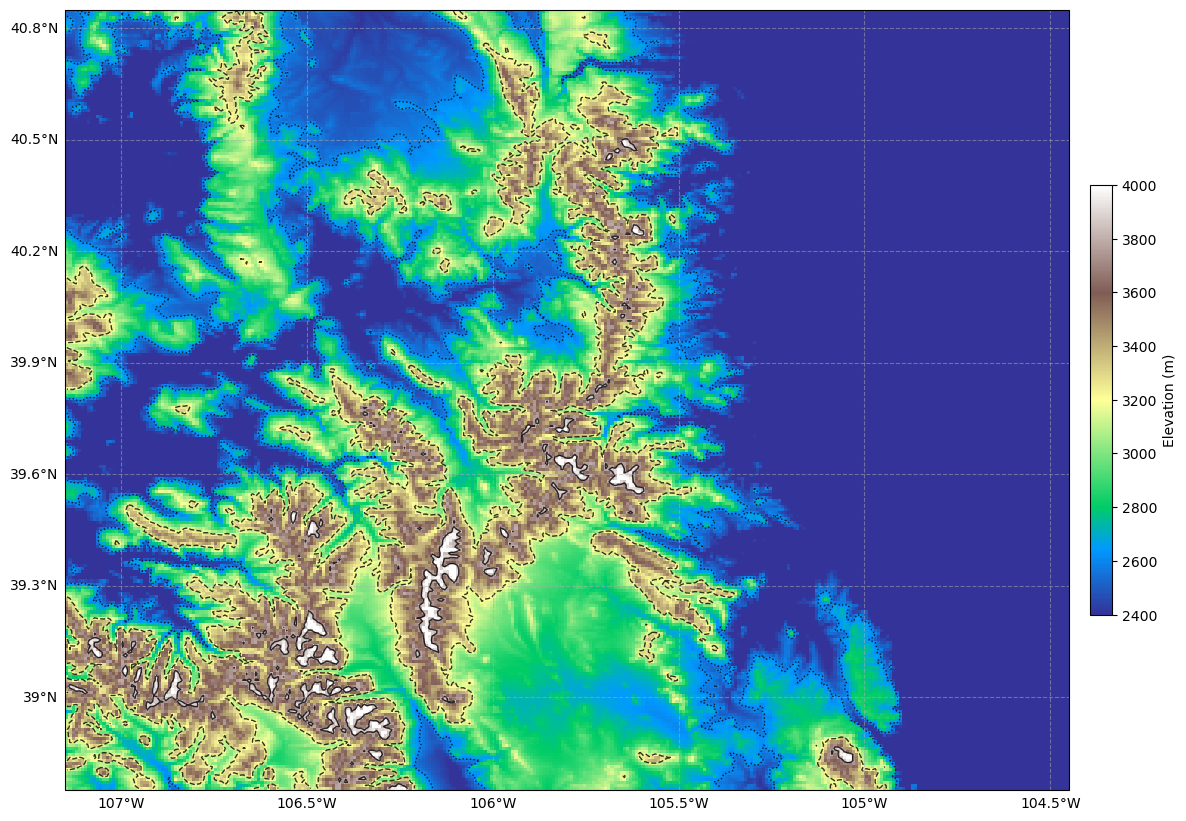

In [22]:
################################
######### Plot Elev #########
################################

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

mesh_min = 2400
mesh_max = 4000
lon2d, lat2d = np.meshgrid(elev_subset["lon"], elev_subset["lat"])

elev_levels = [2600, 3200, 3800]
elev_mesh = ax.contour(
    lon2d, lat2d, elev_subset["HGT"], 
    transform=ccrs.PlateCarree(), 
    colors="black", 
    linewidths=1,
    linestyles=["dotted", "dashed", "solid"],
    levels=elev_levels,
    alpha=0.8
  )

elev_mesh = ax.pcolormesh(
    lon2d, lat2d, elev_subset["HGT"], 
    transform=ccrs.PlateCarree(), 
    cmap="terrain",
    vmin=mesh_min, vmax=mesh_max
  )

ax.set_extent([np.min(pr_lon2d), np.max(pr_lon2d), np.min(pr_lat2d), np.max(pr_lat2d)], ccrs.PlateCarree())

ax.margins(x=0, y=0)

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# plot the figure containing all plots
plt.colorbar(elev_mesh, label="Elevation (m)", fraction=0.05, pad=0.02, shrink=0.5)
plt.tight_layout()
plt.show()